# X points, O points, and islands

Reconnection reorganizes the magnetic topology: X points form where field
lines break, O points sit at island centers. MHX detects both from the flux
function. This tutorial runs a longer seeded double-Harris case and reads
its topology. The committed outputs ran on a laptop CPU in under ten
seconds.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import mhx
from mhx.diagnostics import detect_flux_critical_points

simulation = mhx.Simulation(
    shape=(64, 64),
    equilibrium=mhx.PeriodicDoubleHarrisEquilibrium(
        width=0.4,
        perturbation_amplitude=4.0e-3,
        perturbation_mode=(2, 1),
    ),
    resistivity=5.0e-3,
    viscosity=5.0e-3,
    dt=2.0e-2,
    t_end=80.0,
    save_every=200,
    verbose=False,
)
result = simulation.run()
final_flux = np.asarray(result.final_state.psi)

## Detect the critical points

`detect_flux_critical_points` finds local minima of $|\nabla\psi|$ and
classifies each one by the Hessian determinant of $\psi$: saddles are X
points, extrema are O points.

In [2]:
points = detect_flux_critical_points(final_flux, max_points=8)
for point in points:
    x, y = point.position
    print(f"{point.kind} point at ({x:.2f}, {y:.2f}), psi = {point.psi:.4f}")

O point at (1.57, 0.00), psi = -0.8127
O point at (4.61, 3.04), psi = 0.8127
X point at (1.57, 3.04), psi = -0.7892
X point at (4.61, 0.00), psi = 0.7892


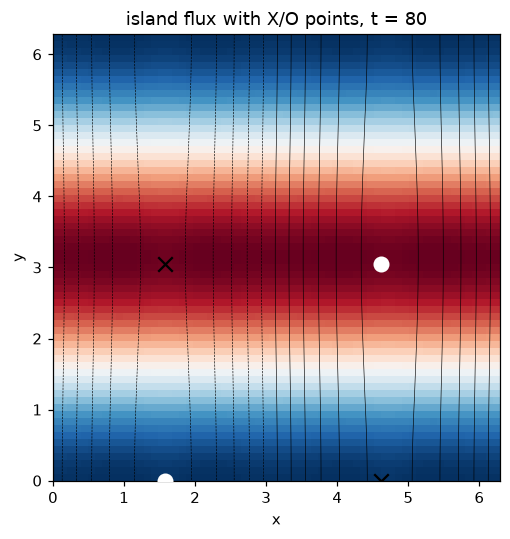

In [3]:
island = final_flux - final_flux.mean(axis=1, keepdims=True)
scale = np.abs(island).max()
extent = (0.0, 2.0 * np.pi, 0.0, 2.0 * np.pi)

figure, axis = plt.subplots(figsize=(5.5, 5), dpi=110)
axis.imshow(
    island.T, origin="lower", extent=extent,
    cmap="RdBu_r", vmin=-scale, vmax=scale,
)
axis.contour(
    np.linspace(*extent[:2], final_flux.shape[0]),
    np.linspace(*extent[2:], final_flux.shape[1]),
    final_flux.T, colors="black", linewidths=0.4, levels=14,
)
for point in points:
    marker = "x" if point.kind == "X" else "o"
    color = "black" if point.kind == "X" else "white"
    axis.scatter(*point.position, marker=marker, s=90, c=color, zorder=3)
axis.set_title(f"island flux with X/O points, t = {result.final_time:.0f}")
axis.set_xlabel("x")
axis.set_ylabel("y")
figure.tight_layout()

## Watch the energy budget

Reconnection converts magnetic energy. The energy history separates the
magnetic and kinetic parts, and the total obeys the exact dissipation
balance on the [model page](../physics/reduced_mhd.md#conservation-laws).

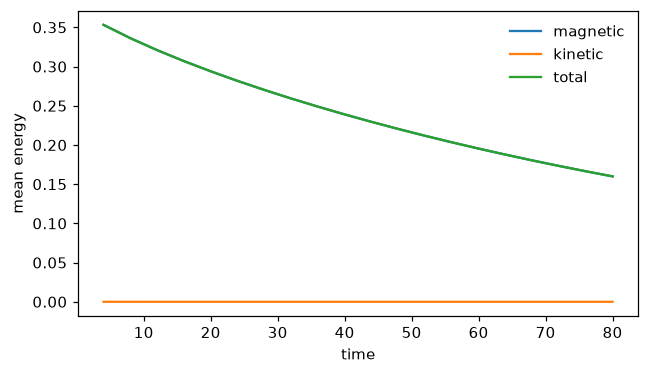

In [4]:
from mhx.diagnostics import trajectory_energies

energies = trajectory_energies(result.trajectory, lengths=result.grid.lengths)
figure, axis = plt.subplots(figsize=(6, 3.5), dpi=110)
axis.plot(energies["time"], energies["magnetic"], label="magnetic")
axis.plot(energies["time"], energies["kinetic"], label="kinetic")
axis.plot(energies["time"], energies["total"], label="total")
axis.set_xlabel("time")
axis.set_ylabel("mean energy")
axis.legend(frameon=False)
figure.tight_layout()

Critical-point counts are discrete diagnostics: report them, but never
differentiate through them. The
[differentiability page](../physics/differentiability.md#what-does-not-differentiate)
explains why, and the
[reconnection campaigns](../validation/reconnection_campaigns.md) show the
validated long-run version of this workflow.